**Exploratory Data Analysis (EDA) on Hotel Booking Dataset**

Internship - CodeAlpha Data Analytics  
Author - Aniket Mishra    
Student ID - CA/DF1/207077

**Objective-**

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Hotel Booking dataset. Through this analysis, we aim to understand the structure of the data, identify trends and patterns, detect data quality issues, test assumptions using statistics and visualizations and generate meaningful business insights.

**Initial Hypotheses -** 

1. City hotels would receive more bookings than resort hotels.  
2. ASome hotel bookings awould be cancelled.  
3. Hotel bookings vary across different months of the year.  
4. Customers who book well in advance tend to have higher cancellation rates.  
5. Some hotel bookings have unusually high room prices (ADR), because of luxury bookings.

In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [2]:
 # Load dataset

df = pd.read_csv("C:/Users/ASUS/Downloads/hotel_booking.csv.zip")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


**Observation -**

The dataset has been loaded successfully. The first five rows provide an overview of the available information. Each row represents one hotel booking.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

**Observation -**

The dataset contains both numerical and categorical variables. A few columns have missing values, such as `country`, `children`, `agent` and `company`. These missing values needs to be examined before further analysis.

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


**Observation -**

The summary statistics provide an overview of the numerical variables in the dataset. Most bookings include `2 adults`, while the average number of children and babies is very low.  
The average lead time is about `104 days`, showcasing that many customers book several months in advance. The maximum lead time is `737 days`, which shows that some customers booked almost two years before their arrival.  
Some variables, such as `lead_time` and `adr`, have a wide range of values, showcasing high variability. Extremely large maximum values may represent outliers.

In [5]:
# Checking Missing Values

df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

**Observation -**

Some columns contain missing values. `Company` column has the highest number of missing values, followed by `agent` and `country`. These missing values should be handled appropriately before analysis.

In [6]:
# Handling Missing Values

df.fillna({"children": 0, "agent": 0}, inplace = True)
df["country"] = df["country"].fillna(df["country"].mode()[0])
df.drop(columns ="company", inplace = True)

**Observation -**

`Children` and `agent` columns contains few missing values. Since they represent  a very small proportion of the dataset, the missing values were replaced with `0`. In case of agent column, missing values generally imean direct bookings without a travel agent.  
`Country` column contains `488` missing values. These were replaced with the most frequently occurring country (mode), as the percentage of missing values is very small.  
At last the `company` column contains extremely high proportion of missing data, therefore, the column was removed from the dataset.

In [7]:
# Checking Duplicate Records

df.duplicated().sum()

np.int64(0)

**Observation -**

No duplicate values were found in the dataset.

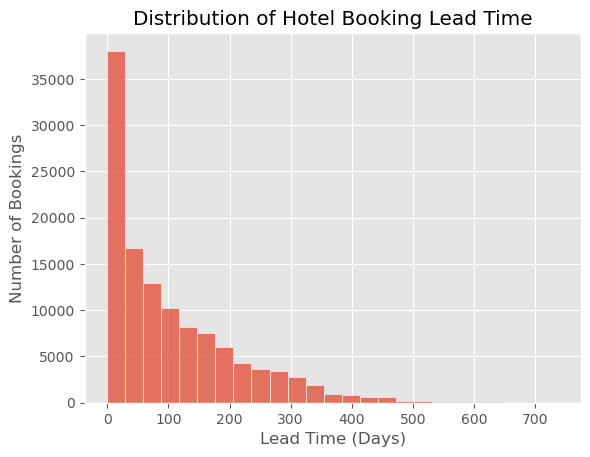

In [8]:
sns.histplot(df["lead_time"], bins = 25)
plt.title("Distribution of Hotel Booking Lead Time")

plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")
plt.show()

**Observation -**

`X-axis` represents the `number of days between booking and arrival`, whereas, `Y-axis` represents the `number of bookings`. Most customers booked their hotel within a short period before their arrival date.  
As the lead time increases, the number of bookings decreases. This shows that long term advance bookings are less common than short term bookings.

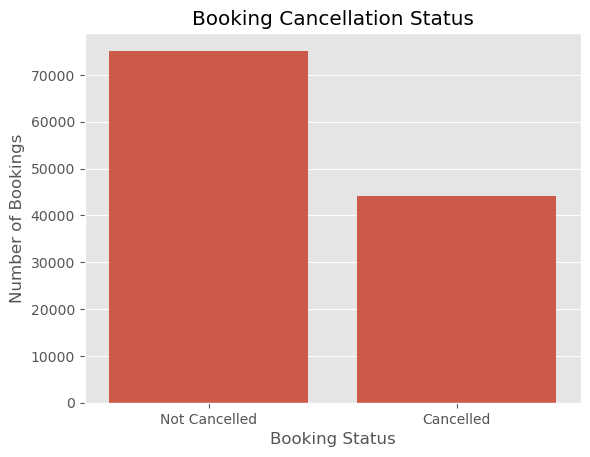

In [9]:
ax = sns.countplot(data = df, x = "is_canceled")
plt.title("Booking Cancellation Status")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Cancelled", "Cancelled"])

plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.show()

**Observation -**

`X-axis` represents the `status of hotel bookings` whether cancelled or not cancelled, whereas, `Y-axis` represents the `total number of bookings` in each category.  
The number of `not cancelled` bookings is much higher than the number of `cancelled` bookings. This shows that most customers completed their reservations successfully. However, a considerable number of bookings were still cancelled.

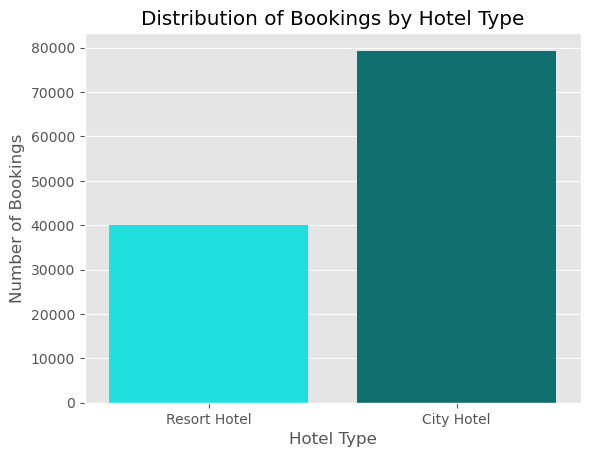

In [10]:
sns.countplot(data = df, x = "hotel", hue = "hotel", palette = ["cyan", "teal"], legend = False)
plt.title("Distribution of Bookings by Hotel Type")

plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

**Observation -**

The `X-axis` represents the `type of hotel`, whereas, `Y-axis` represents the `total number of bookings` made for each hotel type.   
`City hotel` received significantly more bookings than the `resort hotel`. This shows that customers preferred city hotels over resort hotels.

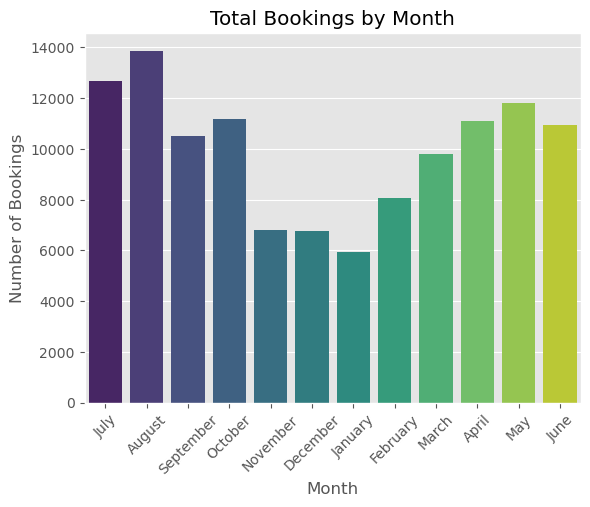

In [11]:
sns.countplot(data = df, x = "arrival_date_month",  hue = "arrival_date_month", palette = "viridis", legend = False)
plt.title("Total Bookings by Month")

plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

**Observation -**

`X-axis` represents the `month in which guests arrived` at the hotel, whereas, `Y-axis` represents the `total number of hotel bookings` for each month.  
The highest number of hotel bookings were in `august`, while `january` had the fewest bookings. Booking increases during the middle of the year and decreases during the winter months, showing seasonal patterns in hotel demand.

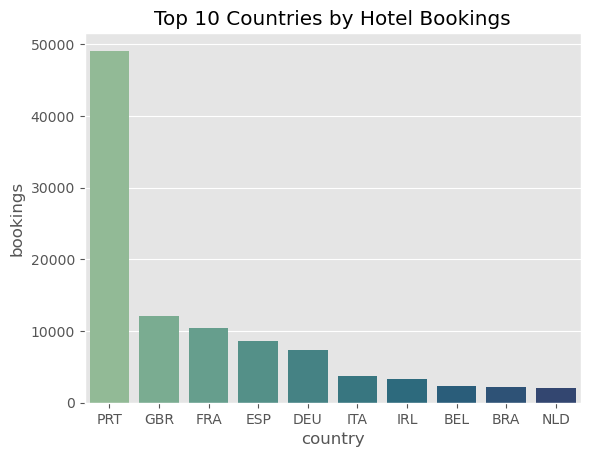

In [12]:
Countries = df["country"].value_counts().head(10)
Countries_df = Countries.reset_index()
Countries_df.columns = ["country", "bookings"]

ax = sns.barplot(data = Countries_df, x = "country", y = "bookings", hue = "country", palette = "crest", legend = False)
plt.title("Top 10 Countries by Hotel Bookings")
plt.show()

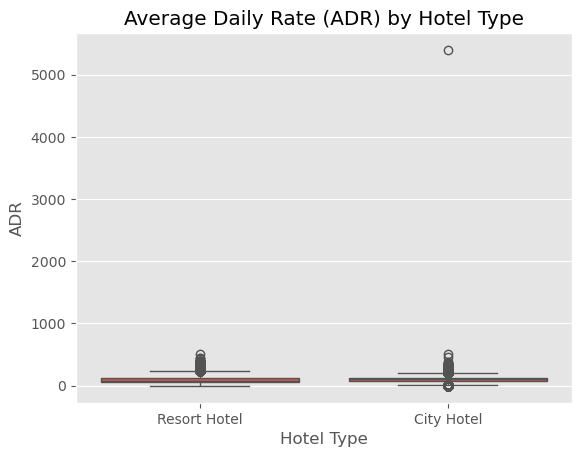

In [13]:
sns.boxplot(data = df, x = "hotel", y = "adr")
plt.title("Average Daily Rate (ADR) by Hotel Type")

plt.xlabel("Hotel Type")
plt.ylabel("ADR")
plt.show()

**Observation -**

`X-axis` represents the `type of hotel`, whereas, `Y-axis` represents the `Average Daily Rate (ADR)`, which is the average room price charged per day.  
ADR varies for both resort hotels and city hotels. Most room prices are concentrated within a similar range, but outliers are present, especially for city hotels.    
Most ADR values are below `300–400`. One city hotel booking has an ADR above `5000`, which is an extreme outlier. It could be  a luxury booking or a data entry issue.

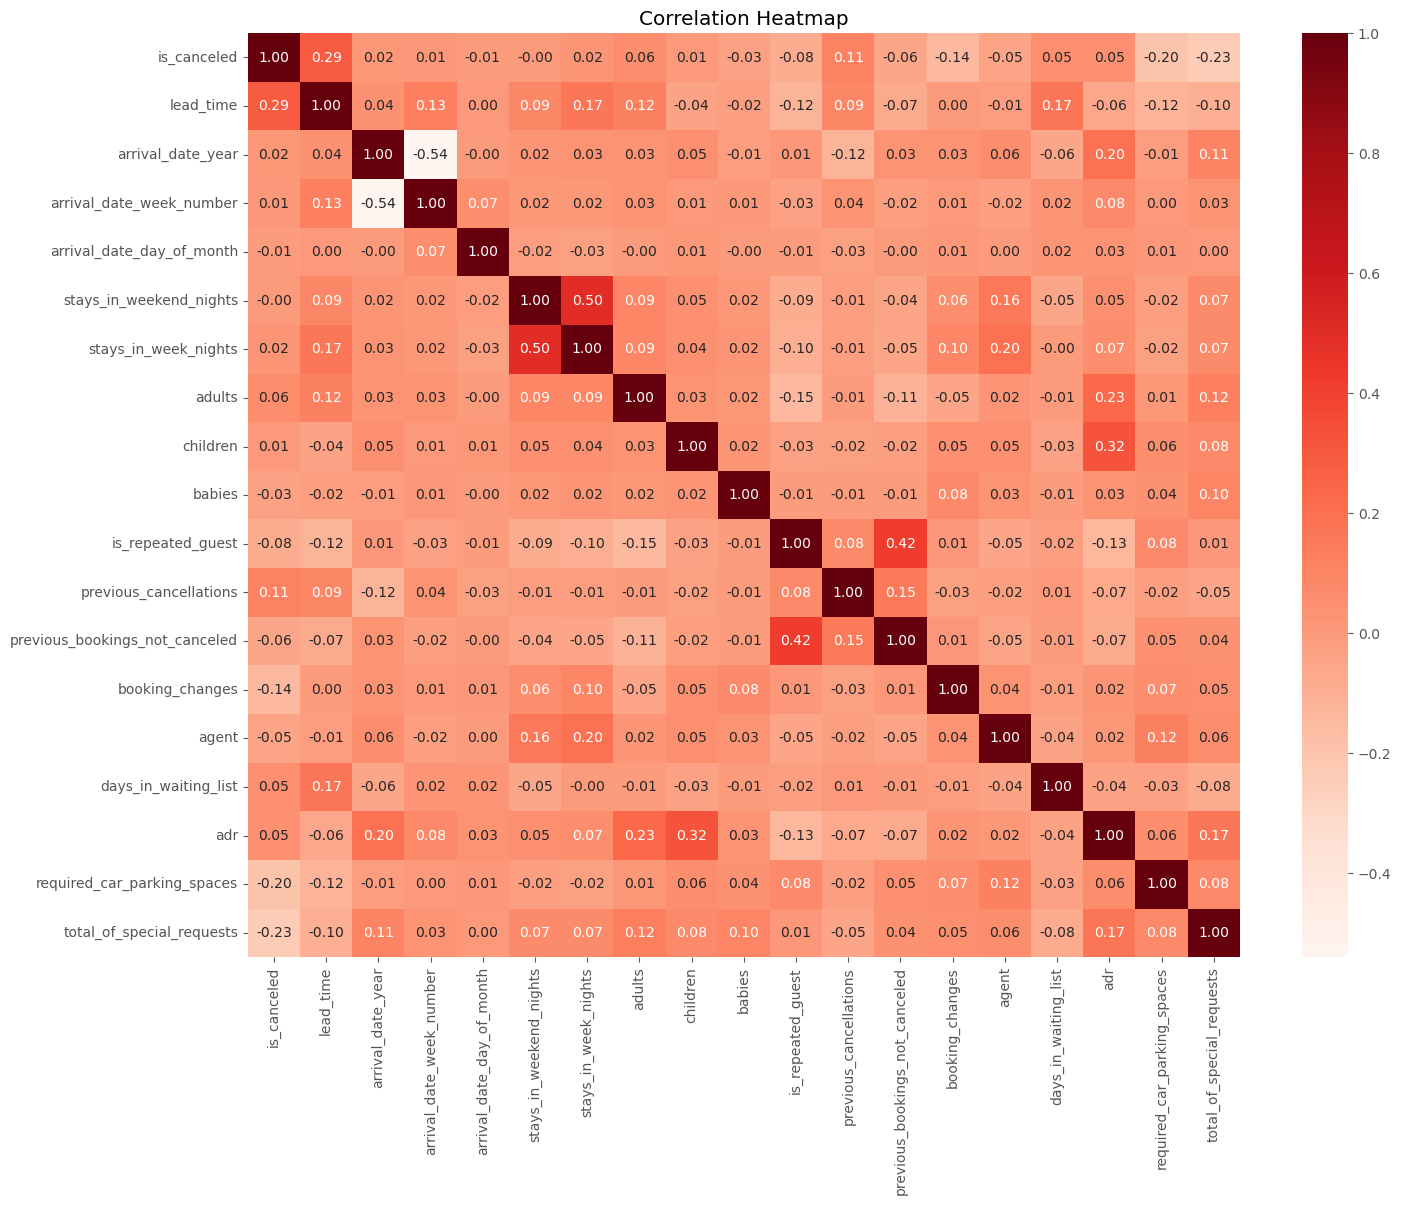

In [14]:
plt.figure(figsize = (16,12))

sns.heatmap(df.corr(numeric_only = True), annot = True, fmt = ".2f", cmap = "Reds")
plt.title("Correlation Heatmap")
plt.show()

**Observation -**

As many correlation values are close to `0`, most variables show weak correlations with each other. Few variables have moderate positive or negative relationships, but there are no very strong correlations between most features.   
This shows that the variables provide different information and are not highly dependent on one another.

**Hypothesis Testing -**

1. The hotel type analysis shows that City hotels have significantly more bookings than resort hotels.  
2. The booking cancellation chart shows that although most bookings were not cancelled, a considerable number of bookings were cancelled. This shows  that cancellations are an important aspect in hotel booking.  
3. The monthly booking analysis shows noticeable differences in booking counts across months, confirming seasonal variation.  
4. The analysis shows that lead time is positively correlated with cancellations. This suggests that customers who book further in advance are somewhat more likely to cancel. However, the relationship is moderate rather than strong.  
5. The box plot of ADR clearly shows several outliers, including a few bookings with exceptionally high room prices. This confirms the presence of outliers in the ADR variable.

**Key Insights -**

1. Most customers booked their stay within 200 days of arrival, while only a few bookings were made very far in advance.  
2. City Hotels receive more bookings than Resort Hotels.  
3. Around one third of all bookings were cancelled, showing that cancellations are a significant issue for hotels.  
4. Hotel demand changes throughout the year. Bookings increase from February onwards, peak in July and August, decrease towards November and December and rise again during May and June.  
5. Portugal had the highest number of bookings, followed by the UK, France, Spain and Germany.  
6. The correlation heatmap showed that most variables had weak correlations, meaning no single factor strongly influenced the others.

**Conclusion -**

1. In this project, Exploratory Data Analysis (EDA) was performed on the Hotel Booking dataset.
2. The analysis included understanding the dataset structure, checking data quality, identifying trends and patterns, testing hypotheses using statistical summaries and visualisations and detecting anomalies such as missing values, duplicate records and outliers.
3. The findings provide valuable insights into customer booking behaviour and hotel operations. This analysis demonstrates how EDA helps transform raw data into meaningful information that supports better business decisions.